In [8]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

def load_mat73(file_path):
    """Load MATLAB v7.3 .mat file and return nested dictionary of numpy arrays"""
    data = {}
    with h5py.File(file_path, 'r') as f:
        def extract_data(name, obj):
            if isinstance(obj, h5py.Dataset):
                return np.array(obj)
            return None
        
        def load_group(group, prefix=''):
            result = {}
            for key in group.keys():
                if key != '#refs#':
                    obj = group[key]
                    full_key = f"{prefix}/{key}" if prefix else key
                    if isinstance(obj, h5py.Dataset):
                        result[key] = np.array(obj)
                    elif isinstance(obj, h5py.Group):
                        result[key] = load_group(obj, full_key)
            return result
        
        for key in f.keys():
            if key != '#refs#':
                if isinstance(f[key], h5py.Group):
                    data[key] = load_group(f[key])
                else:
                    data[key] = np.array(f[key])
    
    return data


def find_monkey_mat(name: str = "dataE.mat") -> Path:
    """Locate neuralSPRT/data/{name} whether cwd is repo root, neuralSPRT/, or parent of proj-rnn-sprt."""
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        for rel in (
            ("neuralSPRT", "data", name),
            ("proj-rnn-sprt", "neuralSPRT", "data", name),
        ):
            p = base.joinpath(*rel)
            if p.is_file():
                return p
    raise FileNotFoundError(
        f"Could not find {name}. Searched upward from {cwd} for "
        "neuralSPRT/data/ and proj-rnn-sprt/neuralSPRT/data/."
    )


cwd = os.getcwd()
# Load the data
mat_file_path = find_monkey_mat("dataE.mat")
print(f"Loading: {mat_file_path}")
data = load_mat73(str(mat_file_path))

Loading: /Users/lijialin/Desktop/Research/proj-rnn-sprt/neuralSPRT/data/dataE.mat


In [9]:
plt.rcParams.update({
        'font.family': 'Arial',
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 9,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.linewidth': 0.75,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.major.width': 1.0,
        'ytick.major.width': 1.0,
        'legend.loc': 'upper right'
    })

In [10]:
info = data["info"]

TM = info['TM'].T     # Trial Matrix 27201 x 70
SpM = info['SpM'].T   # Spike Matrix 27201 x 5000 (raw spikes, 1 ms bin)
FM = info['FM'].T     # Boxcar Filter Firing Rate Matrix 27201 x 500 (50 ms boxcar, 10 ms step)
KM = info['KM'].T     # Alpha-Kernel Firing Rate Matrix 27201 x 5000 (alpha-kernel FR, used in the paper)

In [10]:
print(np.shape(KM))

(27201, 5000)


In [13]:
data = pd.DataFrame(TM)
shape_block = data.iloc[:, 10:30]
mask_bad = shape_block.isin([0, 1]).any(axis=1)
data = data.loc[~mask_bad].reset_index(drop=True)

data = data.rename(columns={
    data.columns[0]: "reward_target",
    data.columns[1]: "saccade_dir",
    data.columns[2]: "rt",
    data.columns[3]: "last_duration",
    data.columns[4]: "target_x_pos",
    data.columns[5]: "target_y_pos",
    data.columns[6]: "RF_side",
    data.columns[7]: "TinOrTout",
    data.columns[8]: "target_color",
    data.columns[9]: "chosen_target_color",
})
data.iloc[:, 10:30]

,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,6.0,7.0,8.0,9.0,8.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8.0,4.0,8.0,9.0,8.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9.0,7.0,9.0,3.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.0,8.0,3.0,3.0,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9.0,9.0,8.0,7.0,2.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27196,7.0,8.0,8.0,7.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27197,9.0,9.0,9.0,9.0,9.0,9.0,5.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27198,9.0,8.0,9.0,7.0,4.0,9.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27199,8.0,5.0,8.0,9.0,8.0,6.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


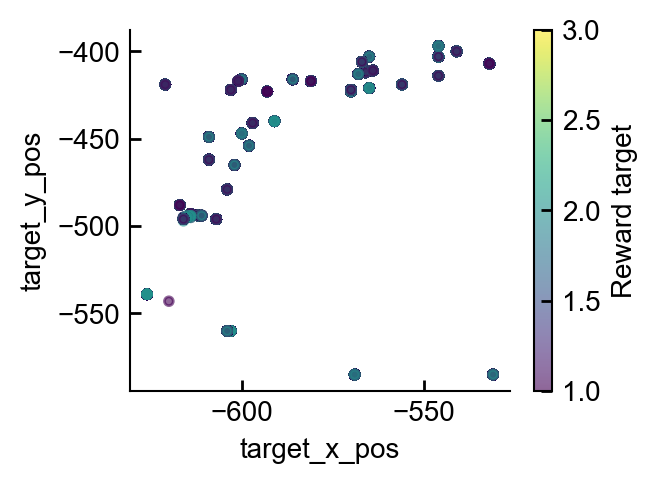

In [14]:
fig, ax = plt.subplots(figsize=(3.35, 2.5))
scatter = ax.scatter(
    data["target_x_pos"],
    data["target_y_pos"],
    c=data["reward_target"],
    alpha=0.6,
    s=10,
)
plt.colorbar(scatter, ax=ax, label="Reward target")
ax.set_xlabel("target_x_pos")
ax.set_ylabel("target_y_pos")
# ax.set_title("Target positions colored by reward target")
plt.tight_layout()
plt.show()

In [15]:
num_equal_trials = (data.iloc[:, 0] == data.iloc[:, 1]).sum()
print(f"Accuracy: {num_equal_trials / len(data)}")

data["is_correct"] = data.iloc[:, 0] == data.iloc[:, 1]
data


Accuracy: 0.8485717436858939


,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,61,62,63,64,65,66,67,68,69,is_correct
0,1.0,1.0,1466.225,199.325,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1,2.0,2.0,1455.100,188.275,-569.0,-585.0,1.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2,1.0,1.0,1225.000,212.150,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
3,1.0,1.0,1330.900,64.000,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4,1.0,1.0,1428.150,162.300,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27196,1.0,1.0,1516.725,250.900,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
27197,1.0,1.0,1938.975,166.275,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
27198,2.0,2.0,1677.925,158.175,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
27199,1.0,2.0,1698.825,179.075,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [16]:
logLR_table = np.array([np.inf, -np.inf, 0.9, -0.9, 0.7, -0.7, 0.5, -0.5, 0.3, -0.3])

shape_block = data.iloc[:, 10:30]
shape_vals = shape_block.to_numpy()
valid_mask = ~np.isnan(shape_vals)
cum_loglr = np.zeros(shape_vals.shape[0])
nums_shape = np.sum(valid_mask, axis=1)  # Count of non-NaN shapes per trial

for i in range(shape_vals.shape[0]):
    ids = shape_vals[i, valid_mask[i]].astype(int)
    cum_loglr[i] = np.sum(logLR_table[ids])

data["cum_loglr"] = cum_loglr
data["nums_shape"] = nums_shape
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,63,64,65,66,67,68,69,is_correct,cum_loglr,nums_shape
0,1.0,1.0,1466.225,199.325,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.8,6
1,2.0,2.0,1455.100,188.275,-569.0,-585.0,1.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,1.8,6
2,1.0,1.0,1225.000,212.150,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-2.3,5
3,1.0,1.0,1330.900,64.000,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-3.4,6
4,1.0,1.0,1428.150,162.300,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.2,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27196,1.0,1.0,1516.725,250.900,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.6,6
27197,1.0,1.0,1938.975,166.275,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-2.8,8
27198,2.0,2.0,1677.925,158.175,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.1,7
27199,1.0,2.0,1698.825,179.075,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.1,7


/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_15169/443431801.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("loglr_bin")["is_right"]


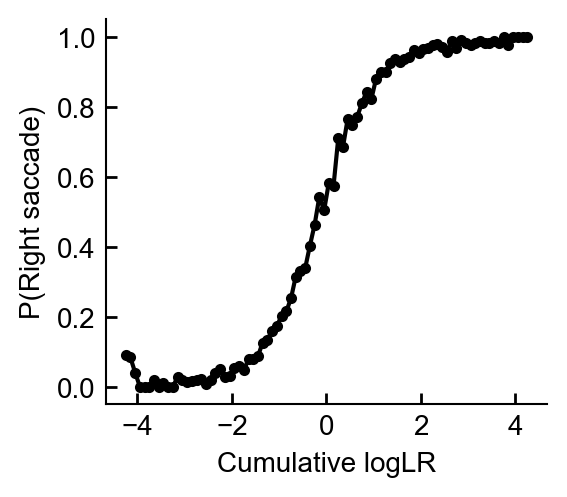

In [14]:
df = data.copy()
df["is_right"] = (df["saccade_dir"] == 2).astype(int)

# ---- build bins ----
x = df["cum_loglr"]
bins = np.arange(
    np.floor(x.min()/0.1)*0.1,
    np.ceil(x.max()/0.1)*0.1 + 0.1,
    0.1
)

df["loglr_bin"] = pd.cut(x, bins=bins)

agg = (
    df.groupby("loglr_bin")["is_right"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

agg["center"] = agg["loglr_bin"].apply(lambda x: x.mid)

# filter sparse bins
agg = agg[agg["count"] > 10]

# ---- plot ----
plt.figure(figsize=(2.85, 2.5))

plt.plot(agg["center"], agg["mean"], marker="o", markersize=3, color="black")
# plt.errorbar(
#     agg["center"],
#     agg["mean"],
#     yerr=agg["std"],
#     fmt="none",
#     capsize=4
# )

plt.xlabel("Cumulative logLR")
plt.ylabel("P(Right saccade)")
# plt.title("Psychometric curve: P(Right) vs cumulative logLR")
# plt.xlim(-3.0, 3.0)
plt.ylim(-0.05, 1.05)
plt.show()

In [10]:
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,63,64,65,66,67,68,69,is_correct,cum_loglr,nums_shape
0,1.0,1.0,1466.225,199.325,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.8,6
1,2.0,2.0,1455.100,188.275,-569.0,-585.0,1.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,1.8,6
2,1.0,1.0,1225.000,212.150,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-2.3,5
3,1.0,1.0,1330.900,64.000,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-3.4,6
4,1.0,1.0,1428.150,162.300,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.2,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27196,1.0,1.0,1516.725,250.900,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.6,6
27197,1.0,1.0,1938.975,166.275,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-2.8,8
27198,2.0,2.0,1677.925,158.175,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.1,7
27199,1.0,2.0,1698.825,179.075,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.1,7


/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_15169/1378014434.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([saccade_col, "rt_bin"])[y_col]
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_15169/1378014434.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df.groupby([saccade_col, "rt_bin"])[y_col].count().reset_index(name='count')


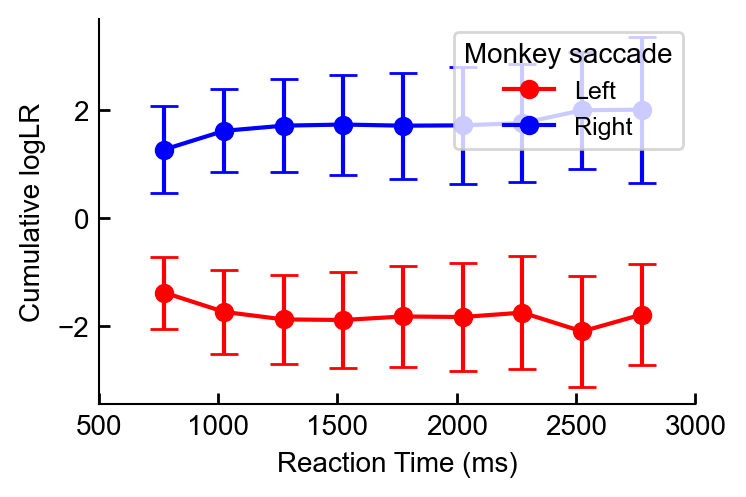

In [15]:
df = data.copy()
reward_col = df.columns[0]
saccade_col = df.columns[1]
rt_col = df.columns[2]
y_col = df.columns[-2]

df = df[df[reward_col] == df[saccade_col]]

rt_min = df[rt_col].min()
rt_max = df[rt_col].max()
bins = np.arange(np.floor(rt_min/100)*100, np.ceil(rt_max/100)*100 + 100, 250)

df["rt_bin"] = pd.cut(df[rt_col], bins=bins)

agg = (
    df.groupby([saccade_col, "rt_bin"])[y_col]
      .agg(["mean", "std"])       
      .reset_index()
)

agg["rt_center"] = agg["rt_bin"].apply(lambda x: x.mid)
bin_counts = df.groupby([saccade_col, "rt_bin"])[y_col].count().reset_index(name='count')
agg = agg.merge(bin_counts, on=[saccade_col, "rt_bin"])
agg = agg[agg['count'] > 20].reset_index(drop=True)


# ---- plot ----
plt.figure(figsize=(3.85, 2.5))

colors = ["red", "blue"]

for direction, label in [(1, "Left"), (2, "Right")]:
    sub = agg[agg[saccade_col] == direction].sort_values("rt_center")

    plt.plot(sub["rt_center"], sub["mean"], marker="o", label=label, color=colors[direction-1])
    plt.errorbar(
        sub["rt_center"],
        sub["mean"],
        yerr=sub["std"],
        fmt="none",
        capsize=5,
        color=colors[direction-1]
    )

plt.xlabel("Reaction Time (ms)")
plt.xlim(500, 3000)
plt.ylabel("Cumulative logLR")
# plt.title("Correct trials — mean ± std per RT bin")
plt.legend(title="Monkey saccade")
plt.show()

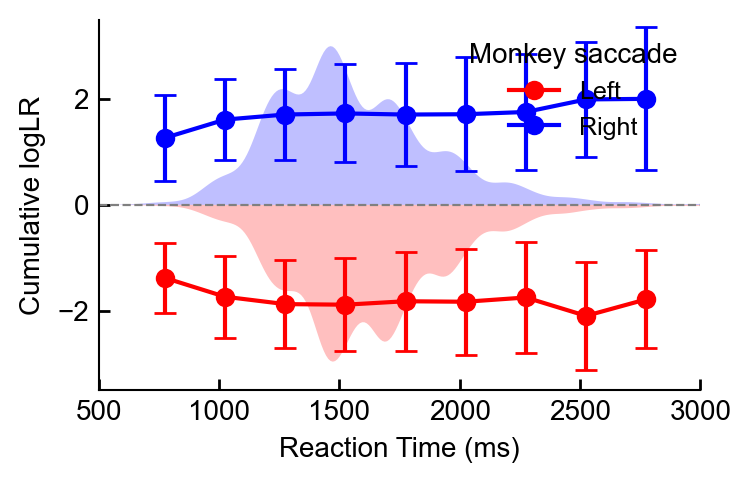

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

df = data.copy()

reward_col = df.columns[0]
saccade_col = df.columns[1]
rt_col = "rt"
y_col = df.columns[-2]  # cum_loglr

df = df[df[reward_col] == df[saccade_col]].copy()
df = df[np.isfinite(df[y_col]) & np.isfinite(df[rt_col])].copy()

rt_min = df[rt_col].min()
rt_max = df[rt_col].max()
bins = np.arange(np.floor(rt_min/100)*100,
                 np.ceil(rt_max/100)*100 + 250,
                 250)

df["rt_bin"] = pd.cut(df[rt_col], bins=bins)

agg = (
    df.groupby([saccade_col, "rt_bin"], observed=True)[y_col]
      .agg(["mean", "std", "count"])
      .reset_index()
)

agg["rt_center"] = agg["rt_bin"].apply(lambda x: x.mid)
agg = agg[agg["count"] > 20].reset_index(drop=True)

rt_grid = np.linspace(rt_min, rt_max, 400)

colors = {1: "red", 2: "blue"}

kde_dict = {}
for direction in [1, 2]:
    rt_vals = df[df[saccade_col] == direction][rt_col].values
    if len(rt_vals) > 10:
        kde = gaussian_kde(rt_vals)
        kde_dict[direction] = kde(rt_grid)
    else:
        kde_dict[direction] = np.zeros_like(rt_grid)

max_density = max(np.max(kde_dict[1]), np.max(kde_dict[2]), 1e-6)

density_height = 3.0  
scale = density_height / max_density

plt.figure(figsize=(3.85, 2.5))

plt.fill_between(
    rt_grid,
    0,
    kde_dict[2] * scale,
    color="blue",
    alpha=0.25,
    linewidth=0
)

plt.fill_between(
    rt_grid,
    0,
    -kde_dict[1] * scale,
    color="red",
    alpha=0.25,
    linewidth=0
)

# 主线 mean ± std
for direction, label in [(1, "Left"), (2, "Right")]:
    sub = agg[agg[saccade_col] == direction].sort_values("rt_center")

    plt.plot(sub["rt_center"], sub["mean"],
             marker="o",
             label=label,
             color=colors[direction],
             zorder=3)

    plt.errorbar(sub["rt_center"],
                 sub["mean"],
                 yerr=sub["std"],
                 fmt="none",
                 capsize=4,
                 color=colors[direction],
                 zorder=3)

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.xlabel("Reaction Time (ms)")
plt.ylabel("Cumulative logLR")
plt.xlim(500, 3000)
plt.ylim(-3.5, 3.5)

plt.legend(title="Monkey saccade", frameon=False)
plt.tight_layout()
plt.show()

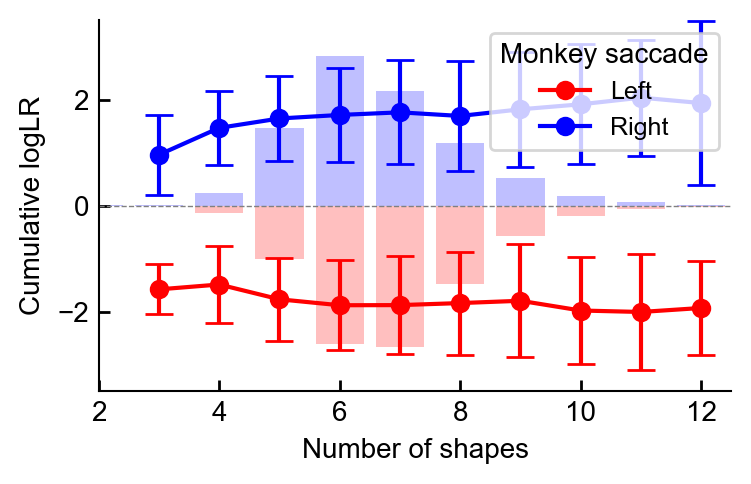

In [11]:
df = data.copy()

reward_col = df.columns[0]
saccade_col = df.columns[1]

# keep only correct trials
df = df[df[reward_col] == df[saccade_col]].copy()

x_col = "nums_shape"
y_col = "cum_loglr"

df = df[np.isfinite(df[y_col])].copy()
agg = (
    df.groupby([saccade_col, x_col])[y_col]
      .agg(["mean", "std", "count"])
      .reset_index()
)

agg = agg[agg["count"] > 5].copy()
agg = agg[agg["nums_shape"] <= 12].copy()

# Frequency of nums_shape at decision: split by cum_loglr > 0 (above) vs < 0 (below)
freq_pos = df[df[y_col] > 0].groupby(x_col, observed=True).size().reindex(range(1, 15)).fillna(0).astype(int)
freq_neg = df[df[y_col] < 0].groupby(x_col, observed=True).size().reindex(range(1, 15)).fillna(0).astype(int)
max_freq = max(freq_pos.max(), freq_neg.max(), 1)
y_range = max(agg["mean"].max() - agg["mean"].min(), 0.5)
scale = 0.7 * y_range / max_freq

# ---- plot ----
plt.figure(figsize=(3.85, 2.5))
colors = {1: "red", 2: "blue"}

for direction, label in [(1, "Left"), (2, "Right")]:
    sub = agg[agg[saccade_col] == direction].sort_values(x_col)

    plt.plot(sub[x_col], sub["mean"], marker="o", label=label, color=colors[direction])
    plt.errorbar(
        sub[x_col],
        sub["mean"],
        yerr=sub["std"],
        fmt="none",
        capsize=5,
        color=colors[direction]
    )

# Frequency distribution: above y=0 (cum>0), below y=0 (cum<0)
plt.bar(freq_pos.index, freq_pos.values * scale, width=0.8, bottom=0, color="blue", alpha=0.25)
plt.bar(freq_neg.index, -freq_neg.values * scale, width=0.8, bottom=0, color="red", alpha=0.25)
plt.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.xlim(2, 12.5)
plt.ylim(-3.5, 3.5)

plt.xlabel("Number of shapes")
plt.ylabel("Cumulative logLR")
# plt.title("Correct trials — cum_loglr by number of shapes (mean ± std)")
plt.legend(title="Monkey saccade")
plt.tight_layout()
plt.show()

In [24]:
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,66,67,68,69,is_correct,cum_loglr,nums_shape,decision_fr,rt_aligned_trace,rt_aligned_valid
0,1.0,1.0,1466.225,199.325,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,True,0.8,6,80.0,"[80.0, 80.0, 40.0, 40.0, 20.0, 0.0, 20.0, 20.0...",True
1,2.0,2.0,1455.100,188.275,-569.0,-585.0,1.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,True,1.8,6,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True
2,1.0,1.0,1225.000,212.150,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,True,-2.3,5,60.0,"[60.0, 20.0, 60.0, 60.0, 60.0, 40.0, 60.0, 20....",True
3,1.0,1.0,1330.900,64.000,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,True,-3.4,6,80.0,"[40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 20.0, 40....",True
4,1.0,1.0,1428.150,162.300,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,True,-0.2,6,40.0,"[40.0, 20.0, 20.0, 20.0, 0.0, 0.0, 0.0, 0.0, 0...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27196,1.0,1.0,1516.725,250.900,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,True,-0.6,6,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True
27197,1.0,1.0,1938.975,166.275,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,True,-2.8,8,0.0,"[20.0, 20.0, 20.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",True
27198,2.0,2.0,1677.925,158.175,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,True,-0.1,7,20.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True
27199,1.0,2.0,1698.825,179.075,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,False,0.1,7,20.0,"[80.0, 100.0, 80.0, 80.0, 80.0, 100.0, 80.0, 6...",True


In [12]:
import statsmodels.formula.api as smf

left = data[data["reward_target"] == 1]
right = data[data["reward_target"] == 2]

left["nums_shape"] = left["nums_shape"].astype("category")
right["nums_shape"] = right["nums_shape"].astype("category")

model1 = smf.ols(
    "cum_loglr ~ C(nums_shape)",
    data=left
).fit(cov_type="HC3")

print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:              cum_loglr   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     11.52
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           3.28e-25
Time:                        23:44:18   Log-Likelihood:                -20510.
No. Observations:               13817   AIC:                         4.105e+04
Df Residuals:                   13803   BIC:                         4.115e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.8556    

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_6123/1534014890.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  left["nums_shape"] = left["nums_shape"].astype("category")
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_6123/1534014890.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  right["nums_shape"] = right["nums_shape"].astype("category")


In [13]:
model2 = smf.ols(
    "cum_loglr ~ C(nums_shape)",
    data=right
).fit(cov_type="HC3")

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:              cum_loglr   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     5.561
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           7.66e-11
Time:                        23:44:28   Log-Likelihood:                -19833.
No. Observations:               13383   AIC:                         3.970e+04
Df Residuals:                   13368   BIC:                         3.981e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.9333    

In [35]:
from scipy.stats import ttest_ind

left_data = data[data["reward_target"] == 1]
right_data = data[data["reward_target"] == 2]

# t-test for cum_loglr between nums_shape=4 and nums_shape=5
cum_loglr_4 = left_data.loc[left_data["nums_shape"] == 4, "cum_loglr"].dropna()
cum_loglr_5 = left_data.loc[left_data["nums_shape"] == 5, "cum_loglr"].dropna()
t_stat_4_5, p_val_4_5 = ttest_ind(cum_loglr_4, cum_loglr_5, equal_var=False)
print(f"T-test between nums_shape=4 and nums_shape=5: t={t_stat_4_5:.4f}, p={p_val_4_5:.4e}")

# t-test for cum_loglr between nums_shape=5 and nums_shape=6
cum_loglr_6 = left_data.loc[left_data["nums_shape"] == 6, "cum_loglr"].dropna()
t_stat_5_6, p_val_5_6 = ttest_ind(cum_loglr_5, cum_loglr_6, equal_var=False)
print(f"T-test between nums_shape=5 and nums_shape=6: t={t_stat_5_6:.4f}, p={p_val_5_6:.4e}")

T-test between nums_shape=4 and nums_shape=5: t=4.9269, p=1.3392e-06
T-test between nums_shape=5 and nums_shape=6: t=5.0910, p=3.7914e-07


In [36]:
from scipy.stats import ttest_ind

left_data = data[data["reward_target"] == 1]
right_data = data[data["reward_target"] == 2]

# t-test for cum_loglr between nums_shape=4 and nums_shape=5
cum_loglr_4 = right_data.loc[right_data["nums_shape"] == 4, "cum_loglr"].dropna()
cum_loglr_5 = right_data.loc[right_data["nums_shape"] == 5, "cum_loglr"].dropna()
t_stat_4_5, p_val_4_5 = ttest_ind(cum_loglr_4, cum_loglr_5, equal_var=False)
print(f"T-test between nums_shape=4 and nums_shape=5: t={t_stat_4_5:.4f}, p={p_val_4_5:.4e}")

# t-test for cum_loglr between nums_shape=5 and nums_shape=6
cum_loglr_6 = right_data.loc[right_data["nums_shape"] == 6, "cum_loglr"].dropna()
t_stat_5_6, p_val_5_6 = ttest_ind(cum_loglr_5, cum_loglr_6, equal_var=False)
print(f"T-test between nums_shape=5 and nums_shape=6: t={t_stat_5_6:.4f}, p={p_val_5_6:.4e}")

T-test between nums_shape=4 and nums_shape=5: t=-3.8698, p=1.2293e-04
T-test between nums_shape=5 and nums_shape=6: t=-1.1700, p=2.4208e-01


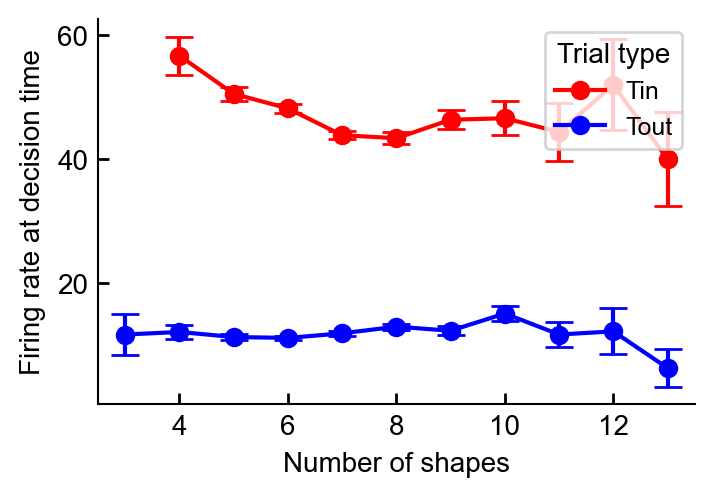

In [11]:
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values] 

decision_fr = []
for i in range(len(data)):
    n = int(data.iloc[i]["nums_shape"])
    if 1 <= n <= 20:
        col_idx = n * 25 - 1
        fr = FM_aligned[i, col_idx]
        decision_fr.append(fr)
    else:
        decision_fr.append(np.nan)

data["decision_fr"] = decision_fr

df_fr = data.dropna(subset=["decision_fr"]).copy()
df_fr = df_fr[df_fr['reward_target'] == df_fr['saccade_dir']]
df_fr = df_fr[df_fr["TinOrTout"].notna()].copy()
agg_fr = (
    df_fr.groupby(["nums_shape", "TinOrTout"], observed=True)["decision_fr"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg_fr = agg_fr[agg_fr["count"] > 10]
agg_fr["sem"] = agg_fr["std"] / np.sqrt(agg_fr["count"])  # standard error of the mean

plt.figure(figsize=(3.85, 2.5))
colors = {1.0: "red", 2.0: "blue"}
labels = {1.0: "Tin", 2.0: "Tout"}

for tinout_val in [1.0, 2.0]:
    sub = agg_fr[agg_fr["TinOrTout"] == tinout_val].sort_values("nums_shape")
    if len(sub) == 0:
        continue
    plt.plot(
        sub["nums_shape"],
        sub["mean"],
        marker="o",
        label=labels.get(tinout_val, str(tinout_val)),
        color=colors.get(tinout_val, "gray"),
    )
    plt.errorbar(
        sub["nums_shape"],
        sub["mean"],
        yerr=sub["sem"],
        fmt="none",
        capsize=5,
        color=colors.get(tinout_val, "gray"),
    )

plt.xlabel("Number of shapes")
plt.ylabel("Firing rate at decision time")
# plt.title("Firing rate at decision vs. nums_shape (Tin vs Tout)")
plt.legend(title="Trial type")
plt.show()

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/30456253.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/30456253.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))


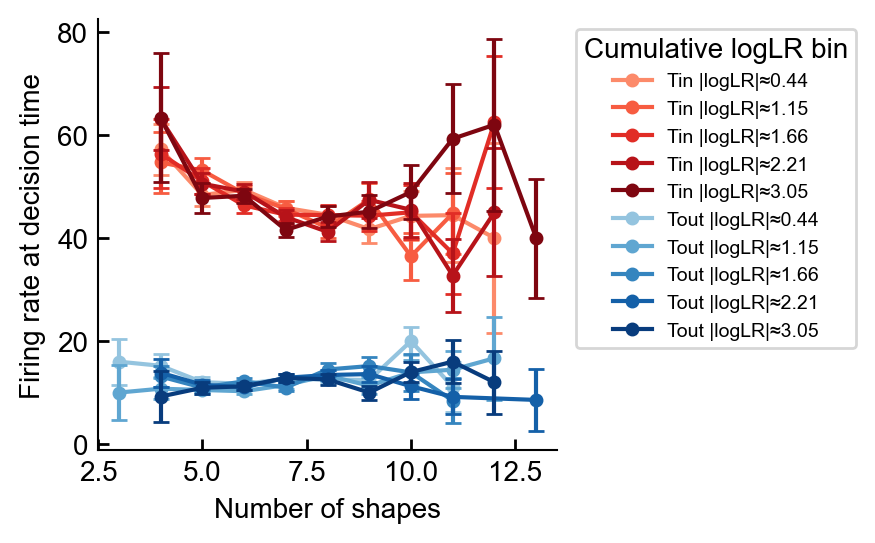

In [9]:
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values] 

decision_fr = []
for i in range(len(data)):
    n = int(data.iloc[i]["nums_shape"])
    if 1 <= n <= 20:
        col_idx = n * 25 - 1
        fr = FM_aligned[i, col_idx]
        decision_fr.append(fr)
    else:
        decision_fr.append(np.nan)

data["decision_fr"] = decision_fr

df_fr = data.dropna(subset=["decision_fr", "cum_loglr"]).copy()
df_fr = df_fr[df_fr["TinOrTout"].notna()].copy()
df_fr = df_fr[np.isfinite(df_fr["cum_loglr"])].copy()

# Group by (nums_shape, TinOrTout, cum_loglr_bin) for gradient by |cumulative logLR|
n_bins = 5
df_fr["abs_cum_loglr"] = np.abs(df_fr["cum_loglr"])
df_fr["cum_loglr_bin"] = pd.qcut(df_fr["abs_cum_loglr"], q=n_bins, duplicates="drop")
bin_centers = df_fr.groupby("cum_loglr_bin", observed=True)["abs_cum_loglr"].mean().sort_values()

agg_fr = (
    df_fr.groupby(["nums_shape", "TinOrTout", "cum_loglr_bin"], observed=True)["decision_fr"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg_fr = agg_fr[agg_fr["count"] > 5]
agg_fr["sem"] = agg_fr["std"] / np.sqrt(agg_fr["count"])

# Gradient colors: Reds for Tin, Blues for Tout
import matplotlib.cm as cm
reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))

plt.figure(figsize=(4.5, 2.8))
for tinout_val, cmap_colors in [(1.0, reds), (2.0, blues)]:
    sub_all = agg_fr[agg_fr["TinOrTout"] == tinout_val]
    bins_seen = sub_all["cum_loglr_bin"].unique()
    bin_order = sorted(bins_seen, key=lambda b: bin_centers.get(b, 0) if b in bin_centers.index else 0)
    for idx, bin_val in enumerate(bin_order):
        sub = sub_all[sub_all["cum_loglr_bin"] == bin_val].sort_values("nums_shape")
        if len(sub) < 2:
            continue
        c = cmap_colors[min(idx, len(cmap_colors) - 1)]
        lr_mid = bin_centers.get(bin_val, float("nan"))
        label = f"{'Tin' if tinout_val == 1.0 else 'Tout'} |logLR|≈{lr_mid:.2f}"
        plt.plot(
            sub["nums_shape"],
            sub["mean"],
            marker="o",
            markersize=4,
            color=c,
            label=label,
        )
        plt.errorbar(
            sub["nums_shape"],
            sub["mean"],
            yerr=sub["sem"],
            fmt="none",
            capsize=3,
            color=c,
        )

plt.xlabel("Number of shapes")
plt.ylabel("Firing rate at decision time")
plt.legend(title="Cumulative logLR bin", fontsize=7, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [42]:
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,64,65,66,67,68,69,is_correct,cum_loglr,nums_shape,decision_fr
0,1.0,1.0,1466.225,199.325,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,0.8,6,80.0
1,2.0,2.0,1455.100,188.275,-569.0,-585.0,1.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,1.8,6,0.0
2,1.0,1.0,1225.000,212.150,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,-2.3,5,60.0
3,1.0,1.0,1330.900,64.000,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,-3.4,6,80.0
4,1.0,1.0,1428.150,162.300,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.2,6,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27196,1.0,1.0,1516.725,250.900,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.6,6,0.0
27197,1.0,1.0,1938.975,166.275,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,-2.8,8,0.0
27198,2.0,2.0,1677.925,158.175,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.1,7,20.0
27199,1.0,2.0,1698.825,179.075,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,0.1,7,20.0


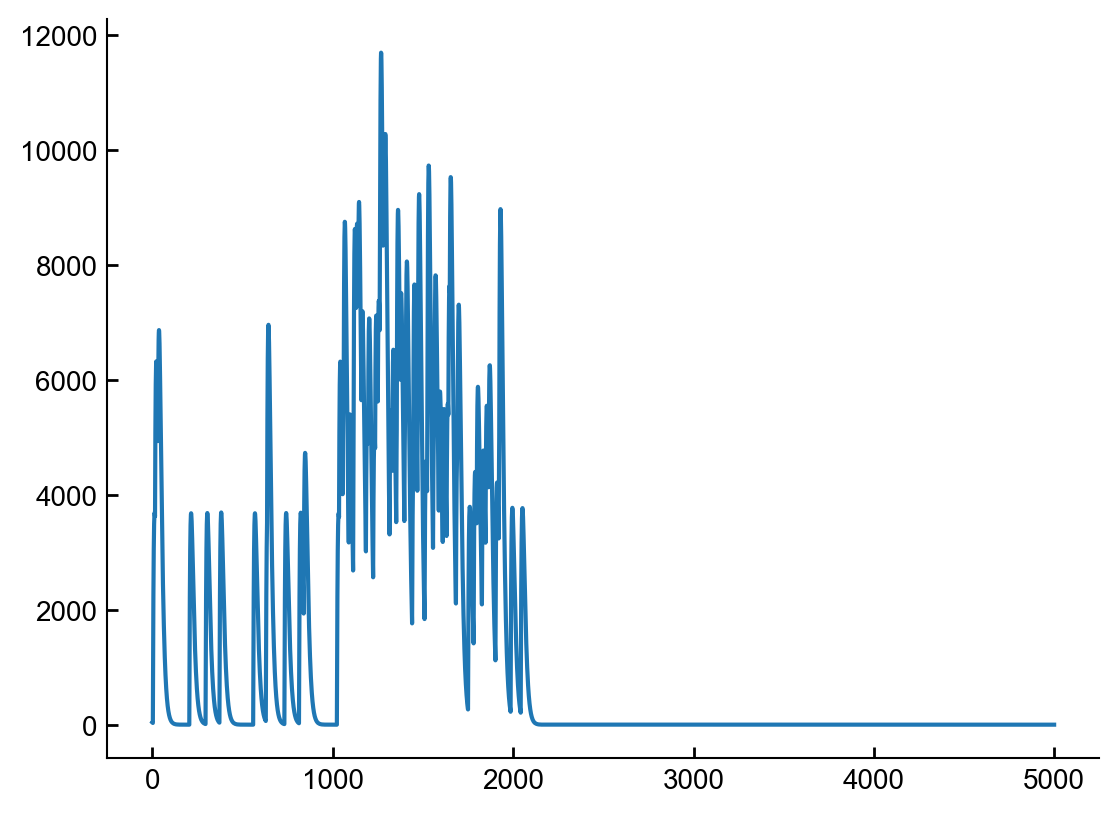

In [13]:
plt.plot(KM[50])
plt.show()

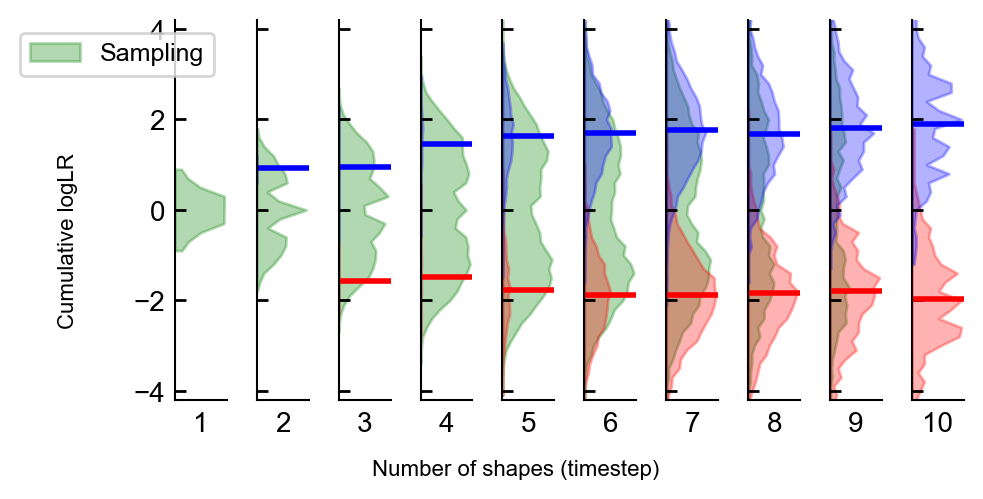

In [17]:
def plot_decision_threshold_distribution_monkey(
    df,
    logLR_table,
    nums_shape_col="nums_shape",
    cum_loglr_col="cum_loglr",
    saccade_col=1,
    shape_block_cols=(10, 30),
    max_timestep=15,
    figsize=(5, 3),
    ylim=(-3.2, 3.2),
    savePNG=False,
    saveSVG=False,
    save_path=None,
):
    """
    Plot cumulative logLR distribution by timestep.
    - Sampling (green): trials still viewing shapes before decision (t < nums_shape).
    - Action (red/blue): trials that decided at t (saccade 1 or 2).
    """
    df = df.dropna(subset=[nums_shape_col, cum_loglr_col]).copy()
    df = df[(df[nums_shape_col] >= 1) & (df[nums_shape_col] <= max_timestep)]

    shape_block = df.iloc[:, shape_block_cols[0] : shape_block_cols[1]]
    shape_vals = shape_block.to_numpy()
    valid_mask = ~np.isnan(shape_vals)

    def partial_cumloglr(i, t):
        ids = shape_vals[i, valid_mask[i]].astype(int)[:t]
        return np.sum(logLR_table[ids])

    rows = []
    for i in range(len(df)):
        n = int(df.iloc[i][nums_shape_col])
        for t in range(1, min(n, max_timestep) + 1):
            if t < n:
                action_type = "sampling"
                ev = partial_cumloglr(i, t)
            else:
                action_type = df.iloc[i, saccade_col] if isinstance(saccade_col, int) else df.iloc[i][saccade_col]
                ev = df.iloc[i][cum_loglr_col]
            if np.isfinite(ev):
                rows.append({"t": t, "action": action_type, "evidence": ev})
    plot_df = pd.DataFrame(rows)
    if plot_df.empty:
        plt.text(0.5, 0.5, "No valid data", ha="center", va="center")
        plt.show()
        return

    fig, axes = plt.subplots(1, max_timestep, figsize=figsize, sharey=True)
    if max_timestep == 1:
        axes = [axes]

    colors = {"sampling": "green", 1.0: "red", 2.0: "blue", 1: "red", 2: "blue"}
    labels = {"sampling": "Sampling", 1.0: "Saccade 1", 2.0: "Saccade 2", 1: "Saccade 1", 2: "Saccade 2"}

    for t in range(max_timestep):
        ax = axes[t]
        timestep_data = plot_df[plot_df["t"] == t + 1]

        for action in ["sampling", 1.0, 2.0]:
            if action == "sampling":
                action_data = timestep_data[timestep_data["action"] == "sampling"]
            else:
                action_data = timestep_data[timestep_data["action"].isin([action, int(action)])]
            if action_data.empty:
                continue

            ev = action_data["evidence"].round(10).to_numpy()
            uniq_vals, counts = np.unique(ev, return_counts=True)

            ax.fill_betweenx(
                uniq_vals, 0, counts,
                color=colors[action], alpha=0.3,
                label=labels.get(action, str(action)) if t == 0 else None,
            )
            if action != "sampling":
                mean_ev = action_data["evidence"].mean()
                ax.axhline(mean_ev, color=colors[action], linewidth=2)

        ax.set_xlabel(str(t + 1))
        ax.set_xlim(0, None)
        ax.set_ylim(ylim)

    fig.text(0.54, 0.03, "Number of shapes (timestep)", ha="center", fontsize=8)
    fig.text(0.1, 0.5, "Cumulative logLR", va="center", rotation="vertical", fontsize=8)

    for ax in axes:
        ax.set_xticks([])
        ax.label_outer()

    axes[0].legend(loc="best")
    plt.tight_layout(rect=[0.05, 0.05, 1, 1])

    if savePNG and save_path:
        plt.savefig(save_path + "decision_threshold_distribution.png", dpi=300)
    if saveSVG and save_path:
        plt.savefig(save_path + "decision_threshold_distribution.svg", dpi=300)

    plt.show()

logLR_table = np.array([np.inf, -np.inf, 0.9, -0.9, 0.7, -0.7, 0.5, -0.5, 0.3, -0.3])
correct_data = data[data["reward_target"] == data["saccade_dir"]]
plot_decision_threshold_distribution_monkey(
    correct_data,
    logLR_table,
    saccade_col=1,
    max_timestep=10,
    figsize=(5.2, 2.5),
    ylim=(-4.2, 4.2),
)

In [16]:
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,63,64,65,66,67,68,69,is_correct,cum_loglr,nums_shape
0,1.0,1.0,1466.225,199.325,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.8,6
1,2.0,2.0,1455.100,188.275,-569.0,-585.0,1.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,1.8,6
2,1.0,1.0,1225.000,212.150,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-2.3,5
3,1.0,1.0,1330.900,64.000,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-3.4,6
4,1.0,1.0,1428.150,162.300,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.2,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27196,1.0,1.0,1516.725,250.900,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.6,6
27197,1.0,1.0,1938.975,166.275,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-2.8,8
27198,2.0,2.0,1677.925,158.175,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,-0.1,7
27199,1.0,2.0,1698.825,179.075,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.1,7


/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/3365173777.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.35, 0.95, 5))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/3365173777.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.35, 0.95, 5))


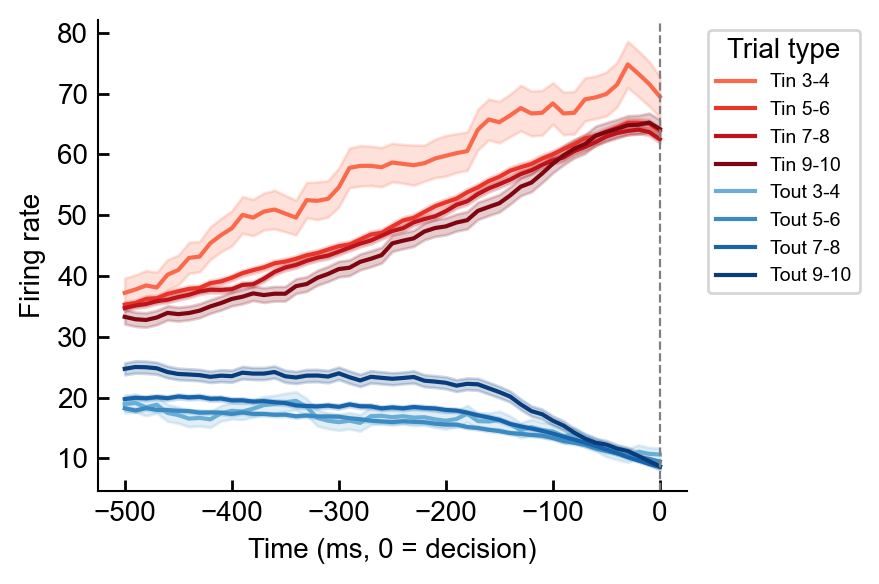

In [11]:
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values]

n_pre = 50  # 400ms before decision
window_bins = n_pre + 1  # include decision
time_ms = np.arange(-n_pre * 10, 1, 10)  # -400, -390, ..., 0 ms (41 points)

# Extract rt-aligned traces for each trial
traces = []
valid_rt = []
for i in range(len(data)):
    rt_ms = data.iloc[i]["rt"]
    col_at_rt = int(rt_ms / 10)
    col_start = col_at_rt - n_pre
    if col_start < 0:
        valid_rt.append(False)
        traces.append(np.full(window_bins, np.nan))
        continue
    valid_rt.append(True)
    col_end = col_at_rt + 1
    traces.append(FM_aligned[i, col_start:col_end])

data["rt_aligned_trace"] = traces
data["rt_aligned_valid"] = valid_rt

# Filter valid trials (rt >= 400ms for full window)
df_rt = data[data["rt_aligned_valid"]].copy()
df_rt = df_rt.dropna(subset=["TinOrTout", "nums_shape"]).copy()
df_rt = df_rt[(df_rt["nums_shape"] >= 1) & (df_rt["nums_shape"] <= 10)].copy()
df_rt = df_rt[df_rt["reward_target"] == df_rt["saccade_dir"]].copy()

# Bin nums_shape for gradient (5 levels to keep legend readable)
df_rt["nums_bin"] = pd.cut(df_rt["nums_shape"], bins=[0, 2, 4, 6, 8, 10], labels=["1-2", "3-4", "5-6", "7-8", "9-10"])
df_rt = df_rt.dropna(subset=["nums_bin"]).copy()

# Gradient colors by nums_bin: Reds for Tin, Blues for Tout
import matplotlib.cm as cm
bin_labels = ["1-2", "3-4", "5-6", "7-8", "9-10"]
reds = cm.get_cmap("Reds")(np.linspace(0.35, 0.95, 5))
blues = cm.get_cmap("Blues")(np.linspace(0.35, 0.95, 5))
color_map = {("Tin", b): reds[i] for i, b in enumerate(bin_labels)}
color_map.update({("Tout", b): blues[i] for i, b in enumerate(bin_labels)})

plt.figure(figsize=(4.5, 3))
for tinout_val, label in [(1.0, "Tin"), (2.0, "Tout")]:
    sub = df_rt[df_rt["TinOrTout"] == tinout_val]
    for nb in bin_labels:
        sub_n = sub[sub["nums_bin"] == nb]
        if len(sub_n) < 1:
            continue
        mean_trace = np.nanmean(np.stack(sub_n["rt_aligned_trace"].values), axis=0)
        sem_trace = np.nanstd(np.stack(sub_n["rt_aligned_trace"].values), axis=0) / np.sqrt(len(sub_n))
        c = color_map[(label, nb)]
        plt.plot(time_ms, mean_trace, color=c, label=f"{label} {nb}")
        plt.fill_between(time_ms, mean_trace - sem_trace, mean_trace + sem_trace, color=c, alpha=0.2)

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Time (ms, 0 = decision)")
plt.ylabel("Firing rate")
plt.legend(title="Trial type", fontsize=7, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/2657299737.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.45, 0.9, len(levels)))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/2657299737.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.45, 0.9, len(levels)))


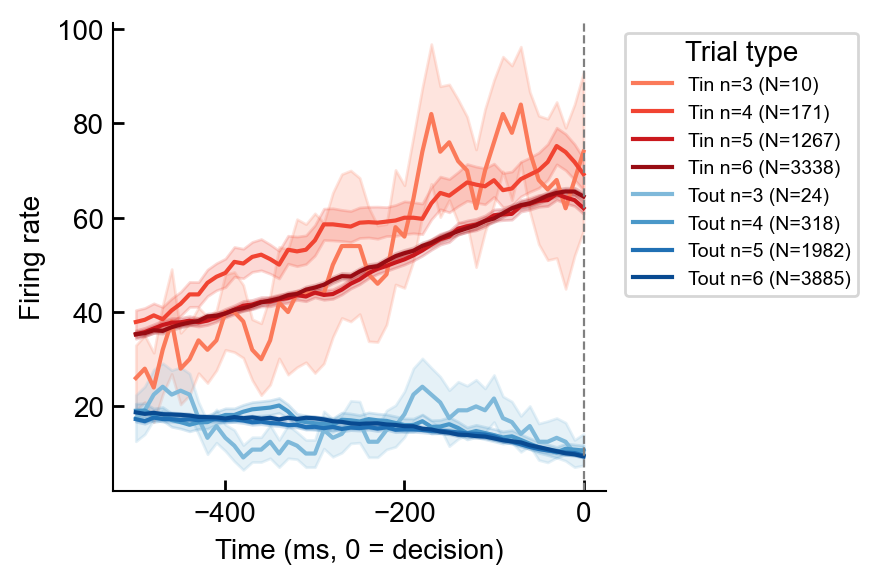

In [12]:
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values]

n_pre = 50  # 400ms before decision
window_bins = n_pre + 1  # include decision
time_ms = np.arange(-n_pre * 10, 1, 10)  # -500..0 if n_pre=50 => -500? (here -500ms); with 10ms/bin

# Extract rt-aligned traces for each trial
traces = []
valid_rt = []
for i in range(len(data)):
    rt_ms = data.iloc[i]["rt"]
    col_at_rt = int(rt_ms / 10)
    col_start = col_at_rt - n_pre
    if col_start < 0:
        valid_rt.append(False)
        traces.append(np.full(window_bins, np.nan))
        continue
    valid_rt.append(True)
    col_end = col_at_rt + 1
    traces.append(FM_aligned[i, col_start:col_end])

data["rt_aligned_trace"] = traces
data["rt_aligned_valid"] = valid_rt

# Filter valid trials (rt >= 400ms for full window)
df_rt = data[data["rt_aligned_valid"]].copy()
df_rt = df_rt.dropna(subset=["TinOrTout", "nums_shape"]).copy()

# 只保留 nums_shape = 3,4,5
df_rt = df_rt[df_rt["nums_shape"].isin([3, 4, 5, 6])].copy()

# 只保留正确 trial（你原来的条件）
df_rt = df_rt[df_rt["reward_target"] == df_rt["saccade_dir"]].copy()

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

levels = [3, 4, 5, 6]

# Tin 用 Reds，Tout 用 Blues，每个 level 一个深浅
reds = cm.get_cmap("Reds")(np.linspace(0.45, 0.9, len(levels)))
blues = cm.get_cmap("Blues")(np.linspace(0.45, 0.9, len(levels)))
color_map = {("Tin", lv): reds[i] for i, lv in enumerate(levels)}
color_map.update({("Tout", lv): blues[i] for i, lv in enumerate(levels)})

plt.figure(figsize=(4.5, 3))
for tinout_val, label in [(1.0, "Tin"), (2.0, "Tout")]:
    sub = df_rt[df_rt["TinOrTout"] == tinout_val]
    for lv in levels:
        sub_n = sub[sub["nums_shape"] == lv]
        if len(sub_n) < 1:
            continue

        arr = np.stack(sub_n["rt_aligned_trace"].values)  # (n_trials, window_bins)
        mean_trace = np.nanmean(arr, axis=0)
        sem_trace = np.nanstd(arr, axis=0) / np.sqrt(len(sub_n))

        c = color_map[(label, lv)]
        plt.plot(time_ms, mean_trace, color=c, label=f"{label} n={lv} (N={len(sub_n)})")
        plt.fill_between(time_ms, mean_trace - sem_trace, mean_trace + sem_trace, color=c, alpha=0.2)

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Time (ms, 0 = decision)")
plt.ylabel("Firing rate")
plt.legend(title="Trial type", fontsize=7, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
data

,reward_target,saccade_dir,rt,last_duration,target_x_pos,target_y_pos,RF_side,TinOrTout,target_color,chosen_target_color,...,65,66,67,68,69,is_correct,cum_loglr,nums_shape,rt_aligned_trace,rt_aligned_valid
0,1.0,1.0,1466.225,199.325,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,0.8,6,"[80.0, 80.0, 40.0, 40.0, 20.0, 0.0, 20.0, 20.0...",True
1,2.0,2.0,1455.100,188.275,-569.0,-585.0,1.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,1.8,6,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True
2,1.0,1.0,1225.000,212.150,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,-2.3,5,"[60.0, 20.0, 60.0, 60.0, 60.0, 40.0, 60.0, 20....",True
3,1.0,1.0,1330.900,64.000,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,-3.4,6,"[40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 20.0, 40....",True
4,1.0,1.0,1428.150,162.300,-569.0,-585.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,-0.2,6,"[40.0, 20.0, 20.0, 20.0, 0.0, 0.0, 0.0, 0.0, 0...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27196,1.0,1.0,1516.725,250.900,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,-0.6,6,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True
27197,1.0,1.0,1938.975,166.275,-531.0,-585.0,2.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,-2.8,8,"[20.0, 20.0, 20.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",True
27198,2.0,2.0,1677.925,158.175,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,-0.1,7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True
27199,1.0,2.0,1698.825,179.075,-531.0,-585.0,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,0.1,7,"[80.0, 100.0, 80.0, 80.0, 80.0, 100.0, 80.0, 6...",True


/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/3744181718.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/3744181718.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))


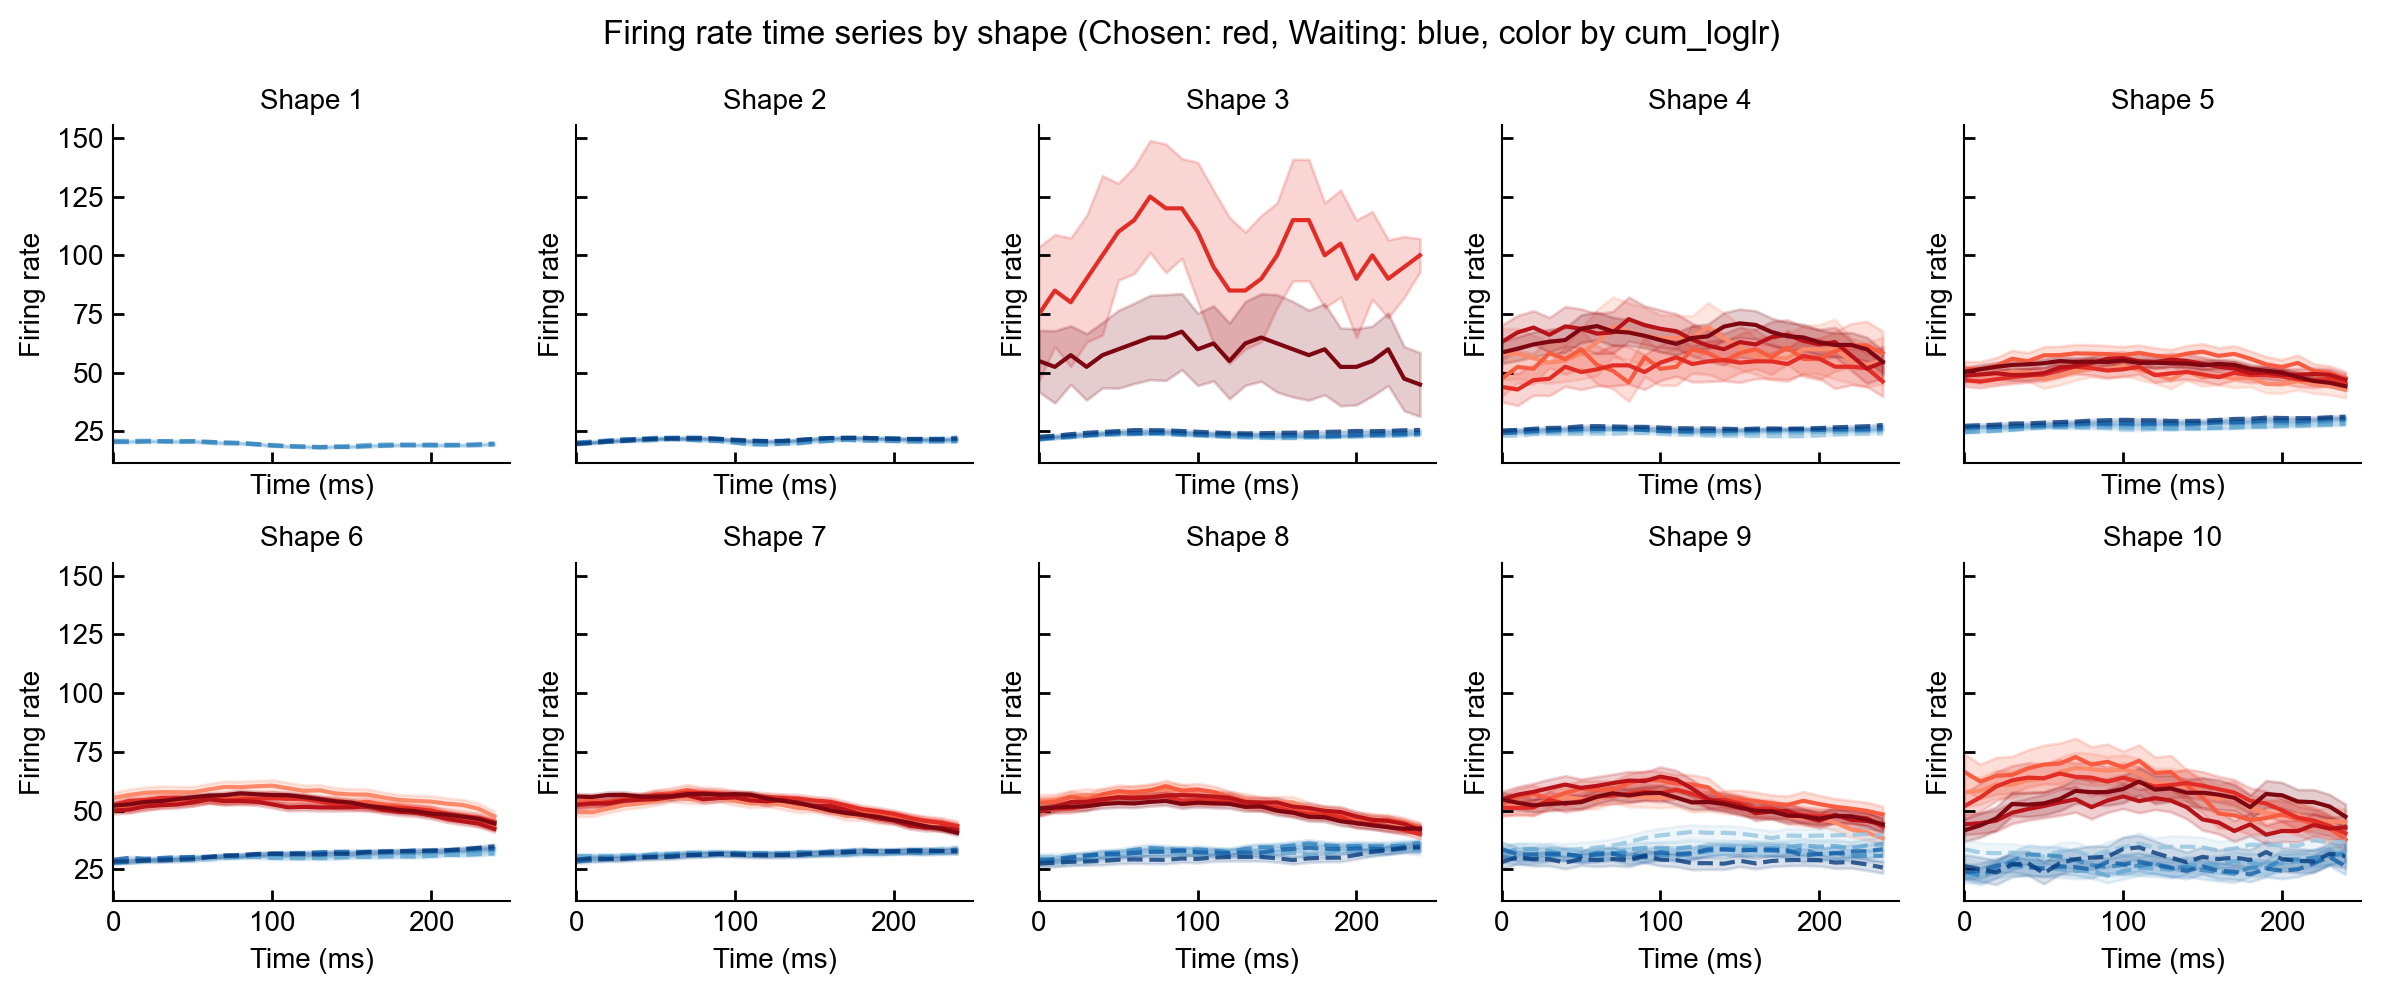

In [13]:
# FR vs time (shape 1-10), color by cum_loglr; Chosen (red) vs Waiting (blue)
# FM: 500 cols, 10ms each. 25 cols per shape (250ms). End of shape k: col k*25-1
logLR_table = np.array([np.inf, -np.inf, 0.9, -0.9, 0.7, -0.7, 0.5, -0.5, 0.3, -0.3])
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
FM_aligned = FM[~mask_bad_fr.values]
shape_vals = data.iloc[:, 10:30].to_numpy()
valid_mask = ~np.isnan(shape_vals)

# Partial cum_loglr at each shape k (1..10) for each trial
partial_cum = np.full((len(data), 11), np.nan)
for i in range(len(data)):
    ids = shape_vals[i, valid_mask[i]].astype(int)
    for k in range(1, 11):
        if k <= len(ids):
            partial_cum[i, k] = np.sum(logLR_table[ids[:k]])

# Time within each shape: 0, 10, ..., 240 ms (25 points, no binning)
time_within_shape = np.arange(0, 250, 10)

n_bins = 5
df_plot = data[(data["nums_shape"] >= 1) & (data["nums_shape"] <= 20)].copy()
df_plot = df_plot[np.isfinite(df_plot["cum_loglr"])].copy()

import matplotlib.cm as cm
reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))

fig, axes = plt.subplots(2, 5, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

for k in range(1, 11):
    ax = axes[k - 1]
    col_start, col_end = (k - 1) * 25, k * 25

    # Shape-specific cum_loglr: Chosen (final cum) + Waiting (partial at k). Define quantile bins per shape.
    chosen_lr = df_plot.loc[df_plot["nums_shape"] == k, "cum_loglr"].values
    wait_idx = df_plot.index[df_plot["nums_shape"] > k]
    wait_lr = partial_cum[wait_idx, k]
    all_lr = np.concatenate([np.abs(chosen_lr[np.isfinite(chosen_lr)]), np.abs(wait_lr[np.isfinite(wait_lr)])])
    if len(all_lr) < n_bins * 2:
        bin_edges_k = np.array([0, np.percentile(all_lr, 50), np.max(all_lr) + 0.01]) if len(all_lr) > 0 else np.array([0, 1])
    else:
        bin_edges_k = np.percentile(all_lr, np.linspace(0, 100, n_bins + 1))
        bin_edges_k = np.unique(bin_edges_k)
        if len(bin_edges_k) < 2:
            bin_edges_k = np.array([0, np.max(all_lr) + 0.01])

    # Chosen (red): trials that decided at shape k. Bin by |cum_loglr| using shape-k quantiles.
    # chosen_sub = df_plot[df_plot["nums_shape"] == k]

    chosen_sub = df_plot[
    (df_plot["nums_shape"] == k) &
    (df_plot["RF_side"] == df_plot["TinOrTout"])
]
    abs_chosen = np.abs(chosen_sub["cum_loglr"].values)
    for idx in range(min(n_bins, len(bin_edges_k) - 1)):
        lo, hi = bin_edges_k[idx], bin_edges_k[idx + 1]
        sel = (abs_chosen >= lo) & (abs_chosen < hi) if idx < len(bin_edges_k) - 2 else (abs_chosen >= lo)
        sub = chosen_sub.iloc[sel]
        if len(sub) < 2:
            continue
        traces = np.array([FM_aligned[i, col_start:col_end] for i in sub.index if i < len(FM_aligned)])
        if len(traces) < 2:
            continue
        mean_fr = np.nanmean(traces, axis=0)
        sem_fr = np.nanstd(traces, axis=0) / np.sqrt(len(traces))
        lr_mid = np.mean(abs_chosen[sel])
        ax.plot(time_within_shape, mean_fr, color=reds[idx], label=f"Chosen |LR|≈{lr_mid:.2f}")
        ax.fill_between(time_within_shape, mean_fr - sem_fr, mean_fr + sem_fr, color=reds[idx], alpha=0.2)

    # Waiting (blue): trials with nums_shape > k. Bin by |partial_cum at k| using shape-k quantiles.
    wait_mask = df_plot["nums_shape"] > k
    if np.sum(wait_mask) >= 5:
        data_idx = df_plot.index[wait_mask]
        partial_k = partial_cum[data_idx, k]
        abs_partial = np.abs(partial_k)
        valid_partial = np.isfinite(abs_partial)
        for idx in range(min(n_bins, len(bin_edges_k) - 1)):
            lo, hi = bin_edges_k[idx], bin_edges_k[idx + 1]
            sel = valid_partial & (abs_partial >= lo) & (abs_partial < hi) if idx < len(bin_edges_k) - 2 else valid_partial & (abs_partial >= lo)
            rows = data_idx[sel]
            if len(rows) < 2:
                continue
            traces = np.array([FM_aligned[i, col_start:col_end] for i in rows if i < len(FM_aligned)])
            if len(traces) < 2:
                continue
            mean_fr = np.nanmean(traces, axis=0)
            sem_fr = np.nanstd(traces, axis=0) / np.sqrt(len(traces))
            lr_mid = np.mean(abs_partial[sel])
            ax.plot(time_within_shape, mean_fr, color=blues[idx], linestyle="--", alpha=0.8,
                    label=f"Wait |LR|≈{lr_mid:.2f}")
            ax.fill_between(time_within_shape, mean_fr - sem_fr, mean_fr + sem_fr, color=blues[idx], alpha=0.15)

    ax.set_title(f"Shape {k}")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Firing rate")
    ax.set_xlim(0, 250)

plt.suptitle("Firing rate time series by shape (Chosen: red, Waiting: blue, color by cum_loglr)")
plt.tight_layout()
plt.show()

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/2177278698.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/2177278698.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))


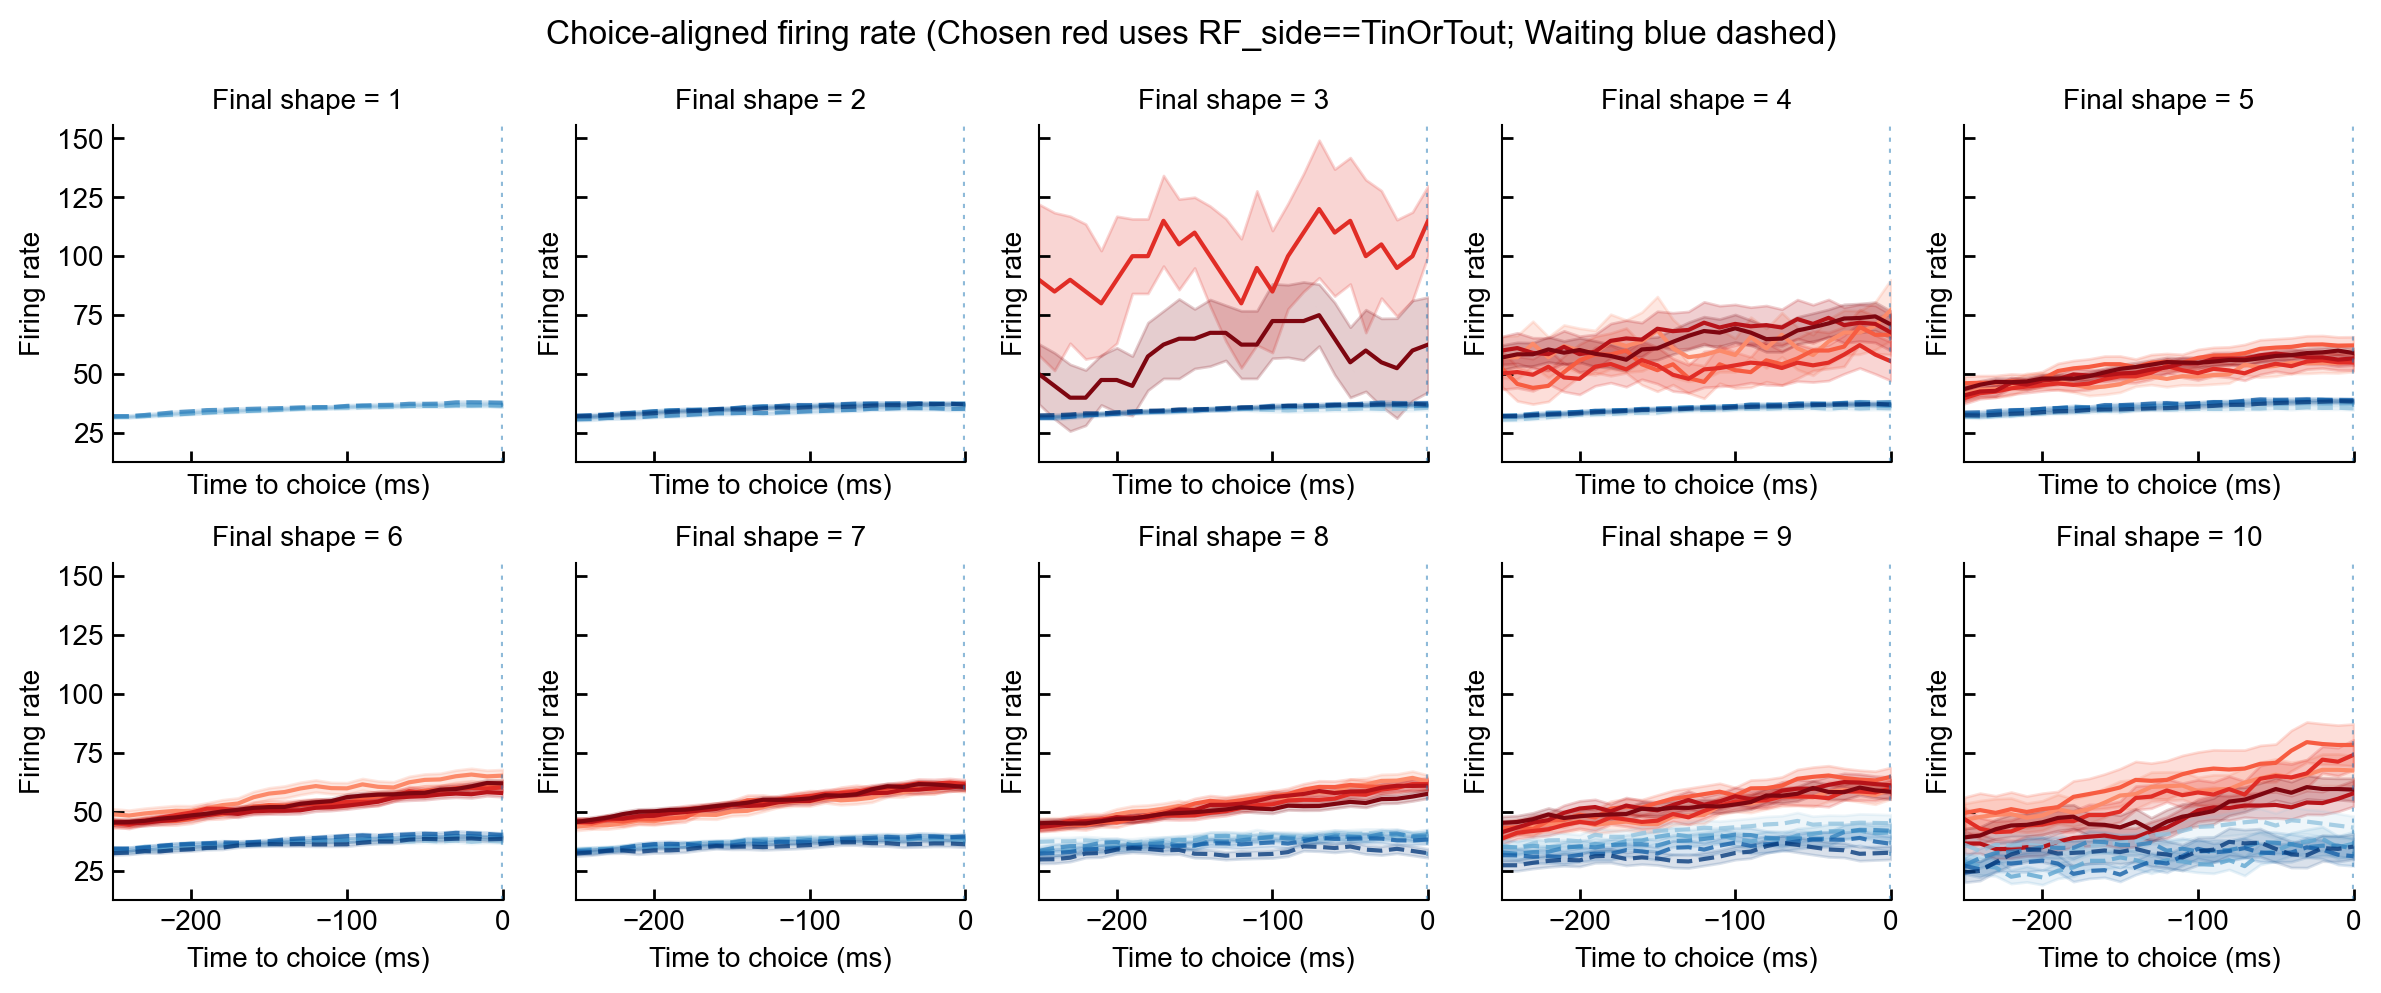

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# 0) 参数
# -----------------------------
bin_ms = 10
bins_per_shape = 25  # 250ms
n_pre = 25           # 40 bins = 400ms before choice
n_post = 0           # 只画到choice时刻；如果你想画choice后，加比如 20 (=200ms)

t_rel = np.arange(-n_pre*bin_ms, (n_post+1)*bin_ms, bin_ms)  # -400..0 (or more)

n_bins = 5
logLR_table = np.array([np.inf, -np.inf, 0.9, -0.9, 0.7, -0.7, 0.5, -0.5, 0.3, -0.3])

# -----------------------------
# 1) 同步过滤：保证 data 与 FM 行对齐
# -----------------------------
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
good_mask = ~mask_bad_fr.values

data2 = data.loc[good_mask].copy().reset_index(drop=True)
FM2 = FM[good_mask]  # 现在 FM2[i] 与 data2.iloc[i] 同一个trial

# -----------------------------
# 2) 计算每个 trial 的 partial cum_loglr（用于 waiting 分箱）
# -----------------------------
shape_vals = data2.iloc[:, 10:30].to_numpy()
valid_mask = ~np.isnan(shape_vals)

partial_cum = np.full((len(data2), 20), np.nan)
for i in range(len(data2)):
    ids = shape_vals[i, valid_mask[i]].astype(int)
    for k in range(1, 11):
        if k <= len(ids):
            partial_cum[i, k] = np.sum(logLR_table[ids[:k]])

k_final = data2["nums_shape"].astype(int).to_numpy()
last_dur = data2["last_duration"].to_numpy()

# last_duration -> bin index within final shape
last_bin = np.floor(last_dur / bin_ms).astype(int)
last_bin = np.clip(last_bin, 0, bins_per_shape - 1) 

choice_col = (k_final - 1) * bins_per_shape + last_bin 

traces_choice = np.full((len(data2), n_pre + n_post + 1), np.nan)
valid_choice = np.zeros(len(data2), dtype=bool)

for i in range(len(data2)):
    cc = int(choice_col[i])
    start = cc - n_pre
    end = cc + n_post + 1  # python右开
    if start >= 0 and end <= FM2.shape[1]:
        traces_choice[i, :] = FM2[i, start:end]
        valid_choice[i] = True

data2["valid_choice_align"] = valid_choice

reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))

fig, axes = plt.subplots(2, 5, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

df_plot = data2[
    (data2["nums_shape"] >= 1) & (data2["nums_shape"] <= 20) &
    np.isfinite(data2["cum_loglr"]) &
    data2["valid_choice_align"]
].copy()

for k in range(1, 11):
    ax = axes[k - 1]

    chosen_lr = df_plot.loc[df_plot["nums_shape"] == k, "cum_loglr"].values

    wait_idx = df_plot.index[df_plot["nums_shape"] > k]
    wait_lr = partial_cum[wait_idx, k]

    all_lr = np.concatenate([
        np.abs(chosen_lr[np.isfinite(chosen_lr)]),
        np.abs(wait_lr[np.isfinite(wait_lr)])
    ])

    if len(all_lr) < n_bins * 2:
        bin_edges_k = np.array([0, np.percentile(all_lr, 50), np.max(all_lr) + 0.01]) if len(all_lr) > 0 else np.array([0, 1])
    else:
        bin_edges_k = np.percentile(all_lr, np.linspace(0, 100, n_bins + 1))
        bin_edges_k = np.unique(bin_edges_k)
        if len(bin_edges_k) < 2:
            bin_edges_k = np.array([0, np.max(all_lr) + 0.01])

    # ---- Chosen (red): nums_shape==k 且 RF_side==TinOrTout
    chosen_sub = df_plot[
        (df_plot["nums_shape"] == k) &
        (df_plot["RF_side"] == df_plot["TinOrTout"])
    ]

    abs_chosen = np.abs(chosen_sub["cum_loglr"].values)

    for b in range(min(n_bins, len(bin_edges_k) - 1)):
        lo, hi = bin_edges_k[b], bin_edges_k[b + 1]
        if b < len(bin_edges_k) - 2:
            sel = (abs_chosen >= lo) & (abs_chosen < hi)
        else:
            sel = (abs_chosen >= lo)

        sub = chosen_sub.loc[sel]
        if len(sub) < 2:
            continue

        idxs = sub.index.to_numpy()
        traces = traces_choice[idxs, :]
        if traces.shape[0] < 2:
            continue

        mean_fr = np.nanmean(traces, axis=0)
        sem_fr = np.nanstd(traces, axis=0) / np.sqrt(traces.shape[0])
        lr_mid = np.nanmean(abs_chosen[sel])

        ax.plot(t_rel, mean_fr, color=reds[b], label=f"Chosen |LR|≈{lr_mid:.2f}")
        ax.fill_between(t_rel, mean_fr - sem_fr, mean_fr + sem_fr, color=reds[b], alpha=0.2)

    # ---- Waiting (blue): nums_shape>k，按 |partial_cum(k)| 分箱
    wait_mask = df_plot["nums_shape"] > k
    if np.sum(wait_mask) >= 5:
        data_idx = df_plot.index[wait_mask]
        partial_k = partial_cum[data_idx, k]
        abs_partial = np.abs(partial_k)
        valid_partial = np.isfinite(abs_partial)

        for b in range(min(n_bins, len(bin_edges_k) - 1)):
            lo, hi = bin_edges_k[b], bin_edges_k[b + 1]
            if b < len(bin_edges_k) - 2:
                sel = valid_partial & (abs_partial >= lo) & (abs_partial < hi)
            else:
                sel = valid_partial & (abs_partial >= lo)

            rows = data_idx[sel]
            if len(rows) < 2:
                continue

            traces = traces_choice[rows.to_numpy(), :]  # 注意：waiting也按它们“自己的choice时刻”对齐
            if traces.shape[0] < 2:
                continue

            mean_fr = np.nanmean(traces, axis=0)
            sem_fr = np.nanstd(traces, axis=0) / np.sqrt(traces.shape[0])
            lr_mid = np.nanmean(abs_partial[sel])

            ax.plot(t_rel, mean_fr, color=blues[b], linestyle="--", alpha=0.8,
                    label=f"Wait |LR|≈{lr_mid:.2f}")
            ax.fill_between(t_rel, mean_fr - sem_fr, mean_fr + sem_fr, color=blues[b], alpha=0.15)

    ax.set_title(f"Final shape = {k}")
    ax.set_xlabel("Time to choice (ms)")
    ax.set_ylabel("Firing rate")
    ax.axvline(0, linestyle=":", alpha=0.5)  # choice moment
    ax.set_xlim(t_rel[0], t_rel[-1])

plt.suptitle("Choice-aligned firing rate (Chosen red uses RF_side==TinOrTout; Waiting blue dashed)")
plt.tight_layout()
plt.show()

/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/2031641858.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
/var/folders/j5/y5g6mhcd7wg0lg4_wsdrql7r0000gn/T/ipykernel_10681/2031641858.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))


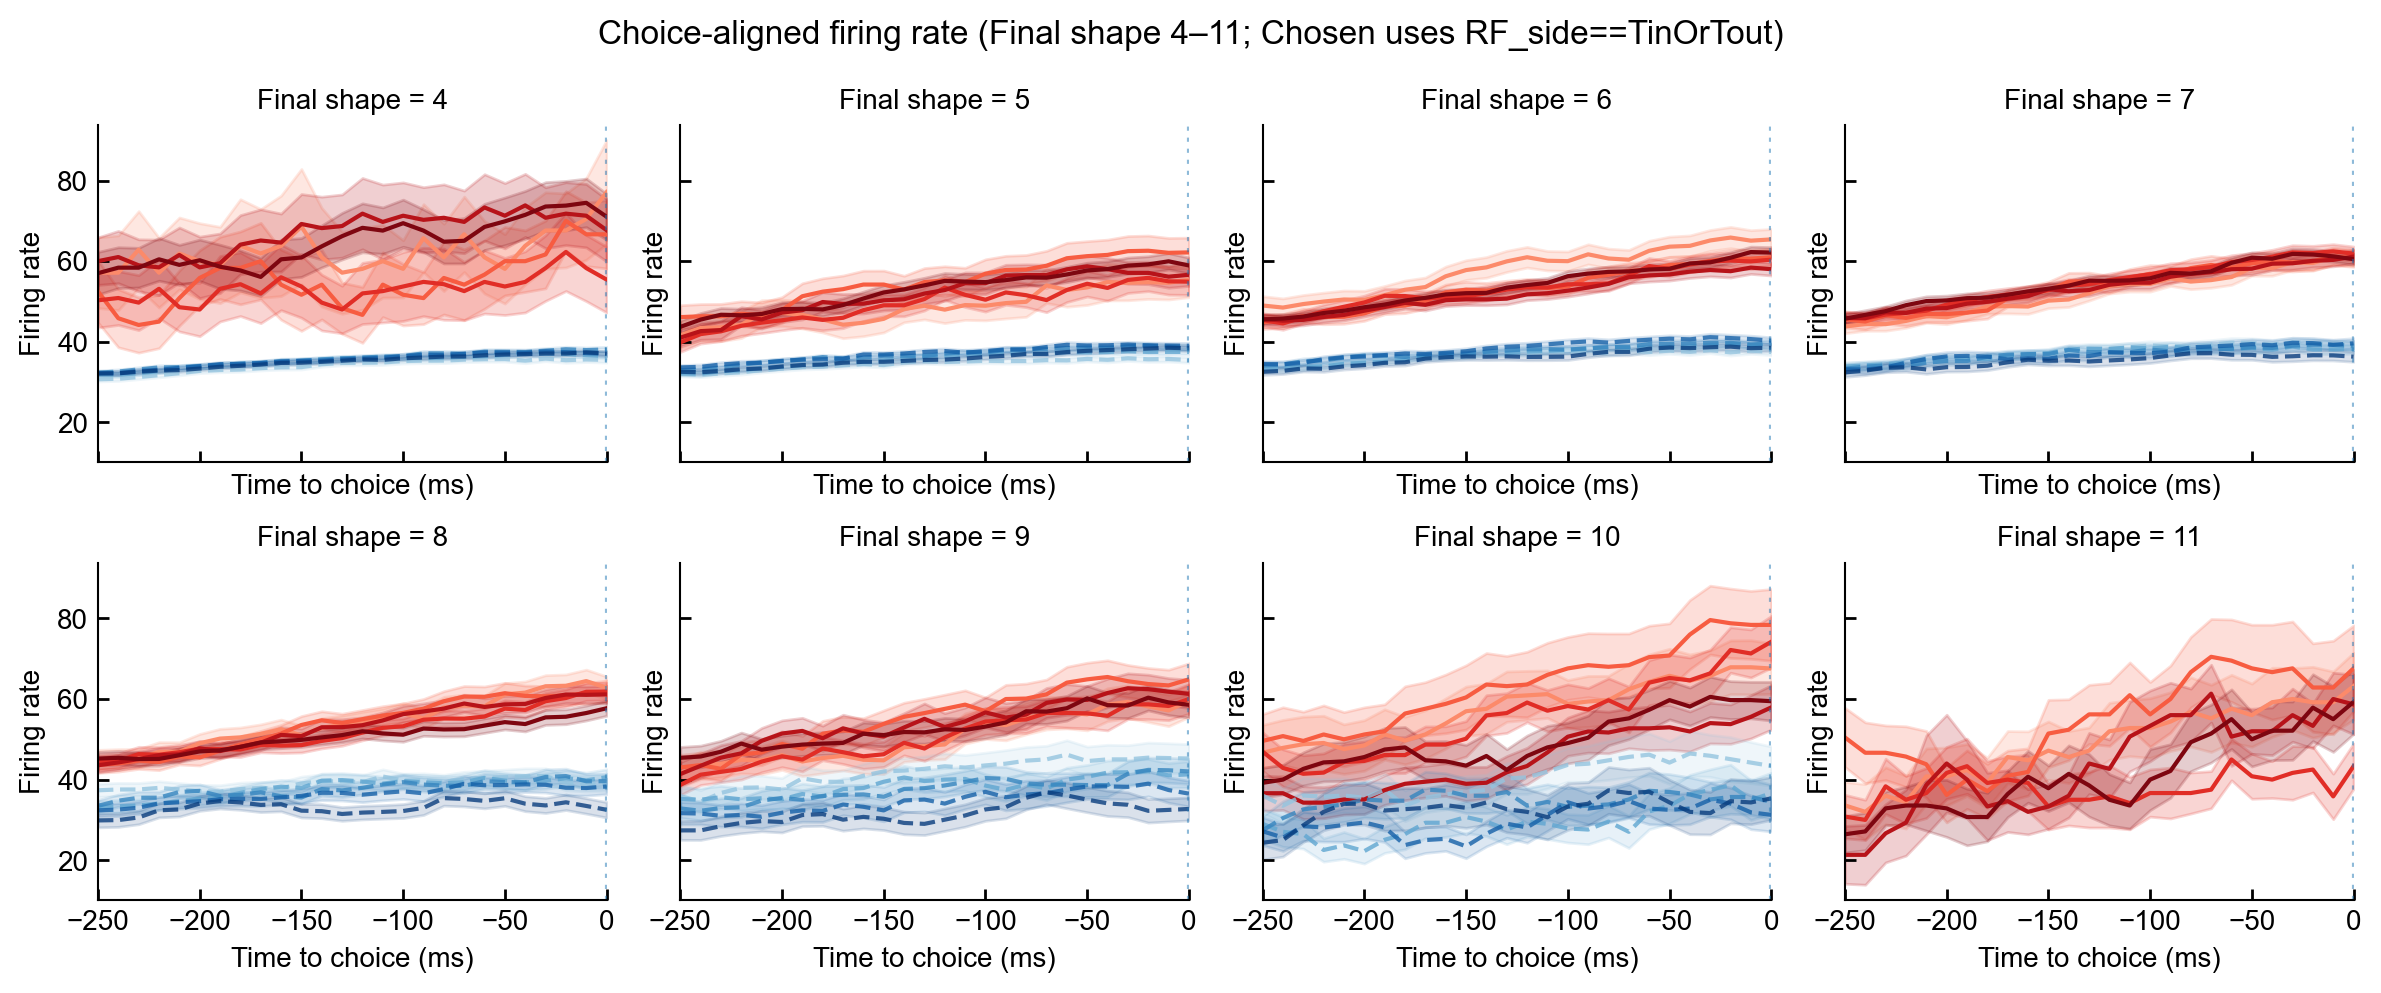

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# 0) 参数
# -----------------------------
bin_ms = 10
bins_per_shape = 25  # 250ms

n_pre = 25           # 25 bins = 250ms before choice (如果要400ms: n_pre=40)
n_post = 0           # 只画到choice时刻；如果你想画choice后，比如 20 (=200ms)

t_rel = np.arange(-n_pre * bin_ms, (n_post + 1) * bin_ms, bin_ms)  # -n_pre*10 .. 0 (or more)

n_bins = 5
logLR_table = np.array([np.inf, -np.inf, 0.9, -0.9, 0.7, -0.7, 0.5, -0.5, 0.3, -0.3])

# -----------------------------
# 1) 同步过滤：保证 data 与 FM 行对齐
# -----------------------------
shape_block_raw = pd.DataFrame(TM).iloc[:, 10:30]
mask_bad_fr = shape_block_raw.isin([0, 1]).any(axis=1)
good_mask = ~mask_bad_fr.values

data2 = data.loc[good_mask].copy().reset_index(drop=True)
FM2 = FM[good_mask]  # 现在 FM2[i] 与 data2.iloc[i] 同一个trial

# -----------------------------
# 2) 计算每个 trial 的 partial cum_loglr（用于 waiting 分箱）
# -----------------------------
shape_vals = data2.iloc[:, 10:30].to_numpy()
valid_mask = ~np.isnan(shape_vals)

partial_cum = np.full((len(data2), 15), np.nan)
for i in range(len(data2)):
    ids = shape_vals[i, valid_mask[i]].astype(int)
    for k in range(1, 11):
        if k <= len(ids):
            partial_cum[i, k] = np.sum(logLR_table[ids[:k]])

# -----------------------------
# 3) 为每个 trial 构造 “choice-aligned” firing rate 片段
# -----------------------------
k_final = data2["nums_shape"].astype(int).to_numpy()
last_dur = data2["last_duration"].to_numpy()

# last_duration -> bin index within final shape
last_bin = np.floor(last_dur / bin_ms).astype(int)
last_bin = np.clip(last_bin, 0, bins_per_shape - 1)

# choice moment column in FM2
choice_col = (k_final - 1) * bins_per_shape + last_bin

win_len = n_pre + n_post + 1
traces_choice = np.full((len(data2), win_len), np.nan)
valid_choice = np.zeros(len(data2), dtype=bool)

for i in range(len(data2)):
    cc = int(choice_col[i])
    start = cc - n_pre
    end = cc + n_post + 1  # python右开
    if start >= 0 and end <= FM2.shape[1] and np.isfinite(last_dur[i]):
        traces_choice[i, :] = FM2[i, start:end]
        valid_choice[i] = True

data2["valid_choice_align"] = valid_choice

# -----------------------------
# 4) 颜色与画布：只画 final shape = 4..11（8个subplot）
# -----------------------------
reds = cm.get_cmap("Reds")(np.linspace(0.4, 0.95, n_bins))
blues = cm.get_cmap("Blues")(np.linspace(0.4, 0.95, n_bins))

k_list = list(range(4, 12))  # 4..11 (8 subplots)

fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

df_plot = data2[
    (data2["nums_shape"] >= 1) & (data2["nums_shape"] <= 20) &
    np.isfinite(data2["cum_loglr"]) &
    data2["valid_choice_align"]
].copy()

for p, k in enumerate(k_list):
    ax = axes[p]

    # Shape-specific quantile bins based on:
    #   Chosen: final |cum_loglr| at k
    #   Waiting: |partial_cum| at k among trials that continue beyond k
    chosen_lr_all = df_plot.loc[df_plot["nums_shape"] == k, "cum_loglr"].values
    wait_idx = df_plot.index[df_plot["nums_shape"] > k]
    wait_lr = partial_cum[wait_idx, k]

    all_lr = np.concatenate([
        np.abs(chosen_lr_all[np.isfinite(chosen_lr_all)]),
        np.abs(wait_lr[np.isfinite(wait_lr)])
    ])

    if len(all_lr) < n_bins * 2:
        bin_edges_k = np.array([0, np.percentile(all_lr, 50), np.max(all_lr) + 0.01]) if len(all_lr) > 0 else np.array([0, 1])
    else:
        bin_edges_k = np.percentile(all_lr, np.linspace(0, 100, n_bins + 1))
        bin_edges_k = np.unique(bin_edges_k)
        if len(bin_edges_k) < 2:
            bin_edges_k = np.array([0, np.max(all_lr) + 0.01])

    # -----------------------------
    # Chosen (red): nums_shape==k 且 RF_side==TinOrTout
    # -----------------------------
    chosen_sub = df_plot[
        (df_plot["nums_shape"] == k) &
        (df_plot["RF_side"] == df_plot["TinOrTout"])
    ]
    abs_chosen = np.abs(chosen_sub["cum_loglr"].values)

    for b in range(min(n_bins, len(bin_edges_k) - 1)):
        lo, hi = bin_edges_k[b], bin_edges_k[b + 1]
        sel = (abs_chosen >= lo) & (abs_chosen < hi) if b < len(bin_edges_k) - 2 else (abs_chosen >= lo)

        sub = chosen_sub.loc[sel]
        if len(sub) < 2:
            continue

        idxs = sub.index.to_numpy()
        traces = traces_choice[idxs, :]
        if traces.shape[0] < 2:
            continue

        mean_fr = np.nanmean(traces, axis=0)
        sem_fr = np.nanstd(traces, axis=0) / np.sqrt(traces.shape[0])
        lr_mid = np.nanmean(abs_chosen[sel])

        ax.plot(t_rel, mean_fr, color=reds[b], label=f"Chosen |LR|≈{lr_mid:.2f}")
        ax.fill_between(t_rel, mean_fr - sem_fr, mean_fr + sem_fr, color=reds[b], alpha=0.2)

    # -----------------------------
    # Waiting (blue): nums_shape>k，按 |partial_cum(k)| 分箱
    # 注意：这里仍然用“各自 trial 的 choice 时刻”对齐（与你现在的版本一致）
    # -----------------------------
    wait_mask = df_plot["nums_shape"] > k
    if np.sum(wait_mask) >= 5:
        data_idx = df_plot.index[wait_mask]
        partial_k = partial_cum[data_idx, k]
        abs_partial = np.abs(partial_k)
        valid_partial = np.isfinite(abs_partial)

        for b in range(min(n_bins, len(bin_edges_k) - 1)):
            lo, hi = bin_edges_k[b], bin_edges_k[b + 1]
            sel = (valid_partial & (abs_partial >= lo) & (abs_partial < hi)) if b < len(bin_edges_k) - 2 else (valid_partial & (abs_partial >= lo))

            rows = data_idx[sel]
            if len(rows) < 2:
                continue

            traces = traces_choice[rows.to_numpy(), :]
            if traces.shape[0] < 2:
                continue

            mean_fr = np.nanmean(traces, axis=0)
            sem_fr = np.nanstd(traces, axis=0) / np.sqrt(traces.shape[0])
            lr_mid = np.nanmean(abs_partial[sel])

            ax.plot(t_rel, mean_fr, color=blues[b], linestyle="--", alpha=0.8,
                    label=f"Wait |LR|≈{lr_mid:.2f}")
            ax.fill_between(t_rel, mean_fr - sem_fr, mean_fr + sem_fr, color=blues[b], alpha=0.15)

    ax.set_title(f"Final shape = {k}")
    ax.set_xlabel("Time to choice (ms)")
    ax.set_ylabel("Firing rate")
    ax.axvline(0, linestyle=":", alpha=0.5)  # choice moment
    ax.set_xlim(t_rel[0], t_rel[-1])

plt.suptitle("Choice-aligned firing rate (Final shape 4–11; Chosen uses RF_side==TinOrTout)")
plt.tight_layout()
plt.show()